In [1]:
from hardware import SLMManager
import torch

sim_mode = True
slm_manager = SLMManager(sim_mode=sim_mode)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')



🎬 Simulation Mode Enabled


In [2]:
import config
from optics_utils import process_parameters
from phase_generators import PhaseGenerator
# 默认参数字典 from config
test_raw_params = {}
test_raw_params.update(config.COMMON_DEFAULTS)
test_raw_params.update(config.OPTIMIZED_DEFAULTS)
test_raw_params.update(config.INTERNAL)

# 添加测试需要的基本信息 (这些信息之前GUI提供)
test_raw_params['shape'] = slm_manager.shape
test_raw_params['N'] = 900 # ROI尺寸

# fix
test_raw_params['focal_length_coarse'] = 58.5

###### 下面的block仅供测试，需要注释掉
#### !! only for test on small CPU (No GPU)
test_raw_params['N'] = 200 # ROI尺寸
test_raw_params['M'] = 3
test_raw_params['lr'] = 0.1
test_raw_params['ni'] = 140
test_raw_params['show_iters'] = 10
test_raw_params['depth_in_focus'] = [-0.5, 0.5]
test_raw_params['depth_out_focus'] = [0.75]

# 调用参数处理函数
final_params = process_parameters(test_raw_params)

# Fresnel lens 
Optimizer2 = PhaseGenerator(final_params, device=device)
Optimizer2.generate(mode='fresnel')
phase_8bit = Optimizer2.update_phase_8bit(215)
if not sim_mode:
    slm_manager.upload(phase_8bit)

Using device: cpu
F/95.38, 58.5 mm
Lens width: 0.613mm
Airy radius: 61.9um
Depth of focus: 9.68mm
Multi-depth planes are used at F=53.7 (-0.5DOF), 63.3 (0.5DOF) mm
Out-of-focus planes are used at Z=43.9 (0.75x) mm
Fresnel Lens: 200x200 px; 3x3 lenses


Using device: cpu
F/95.38, 58.5 mm
Lens width: 0.613mm
Airy radius: 61.9um
Depth of focus: 9.68mm
Multi-depth planes are used at F=53.7 (-0.5DOF), 63.3 (0.5DOF) mm
Out-of-focus planes are used at Z=43.9 (0.75x) mm


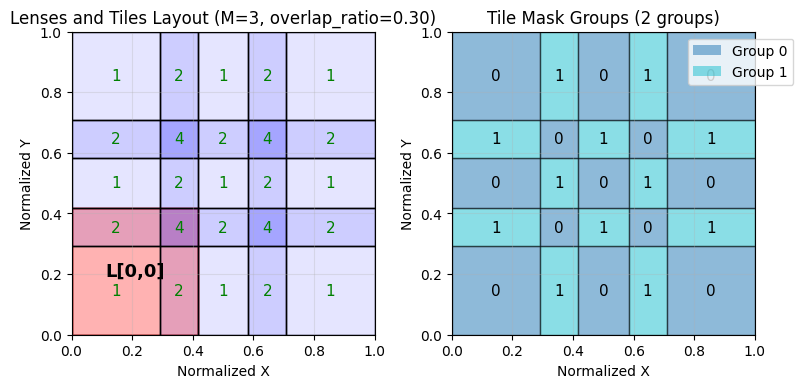


Tile Statistics:
Total tiles: 25
Grid dimensions: 5 x 5
Tiles per group: {0: 13, 1: 12}
Lens contribution distribution: {1: 9, 2: 12, 4: 4}


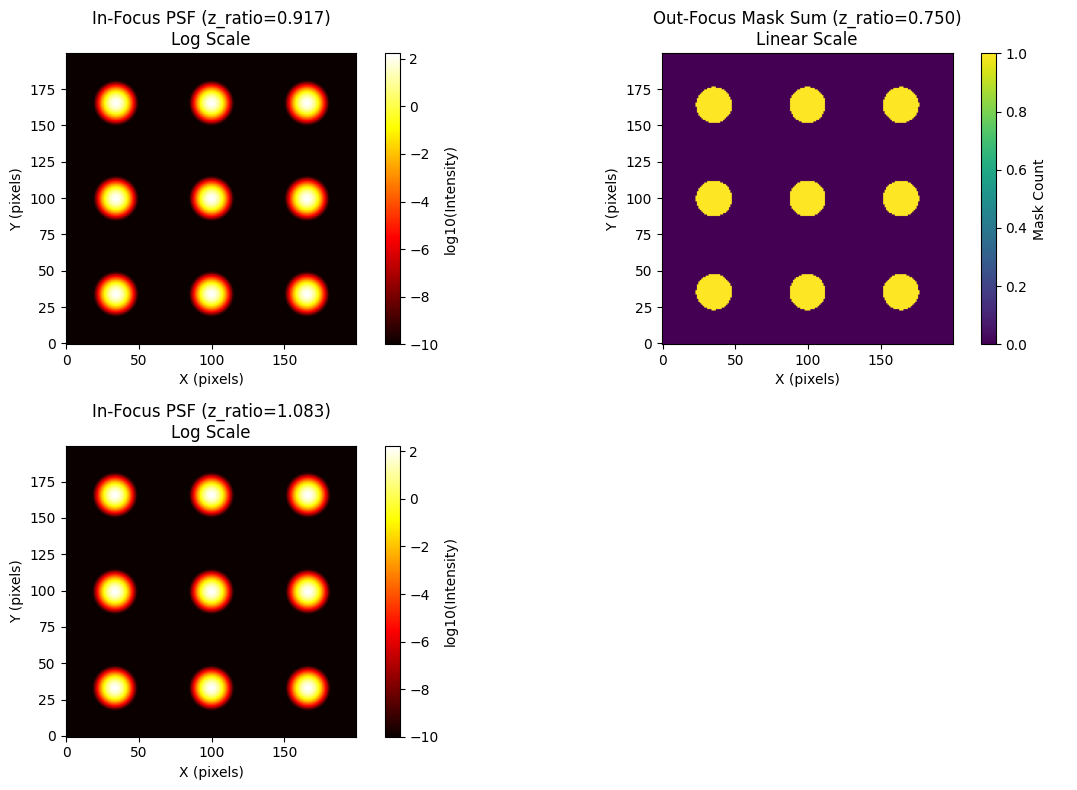

In [3]:
# Optimization prepare
final_params['overlap_ratio'] = 0.3
final_params['airy_correction'] = 0.9
# final_params['mask_count'] = 4
# final_params['interleaving'] = 'coarse2'
final_params['mask_count'] = 2
final_params['interleaving'] = 'coarse1'
Optimizer = PhaseGenerator(final_params, device=device) 
Optimizer._prepare_template()


In [4]:
Optimizer.generate(upsampling=2.0, visualize=False)
phase_8bit = Optimizer.update_phase_8bit(215)
if not sim_mode:
    slm_manager.upload(phase_8bit)

Starting optimization with 140 iterations...
Iter: 1/140
  Focal_mse: 84.9985 Depth_mse: 85.0609 Centroid_loss: 3.7740 Eff_mean: 0.0064 Eff_std: 0.0011
  Masked: 21.5627 Total: 1.9155e+02
Iter: 11/140
  Focal_mse: 48.8160 Depth_mse: 65.1306 Centroid_loss: 4.3795 Eff_mean: 0.2348 Eff_std: 0.0365
  Masked: 15.6352 Total: 1.2671e+02
Iter: 21/140
  Focal_mse: 18.3788 Depth_mse: 32.6406 Centroid_loss: 2.2134 Eff_mean: 0.5536 Eff_std: 0.0215
  Masked: 9.2880 Total: 5.0309e+01
Iter: 31/140
  Focal_mse: 8.2843 Depth_mse: 16.0778 Centroid_loss: 1.6938 Eff_mean: 0.6887 Eff_std: 0.0036
  Masked: 7.3332 Total: 1.8102e+01
Iter: 41/140
  Focal_mse: 4.5779 Depth_mse: 11.3691 Centroid_loss: 2.3319 Eff_mean: 0.7295 Eff_std: 0.0024
  Masked: 6.9301 Total: 8.4050e+00
Iter: 51/140
  Focal_mse: 3.4109 Depth_mse: 9.8045 Centroid_loss: 2.3606 Eff_mean: 0.7519 Eff_std: 0.0036 Masked:
  6.7533 Total: 5.1094e+00
Iter: 61/140
  Focal_mse: 3.0292 Depth_mse: 9.0019 Centroid_loss: 1.8522 Eff_mean: 0.7659 Eff_std: 0

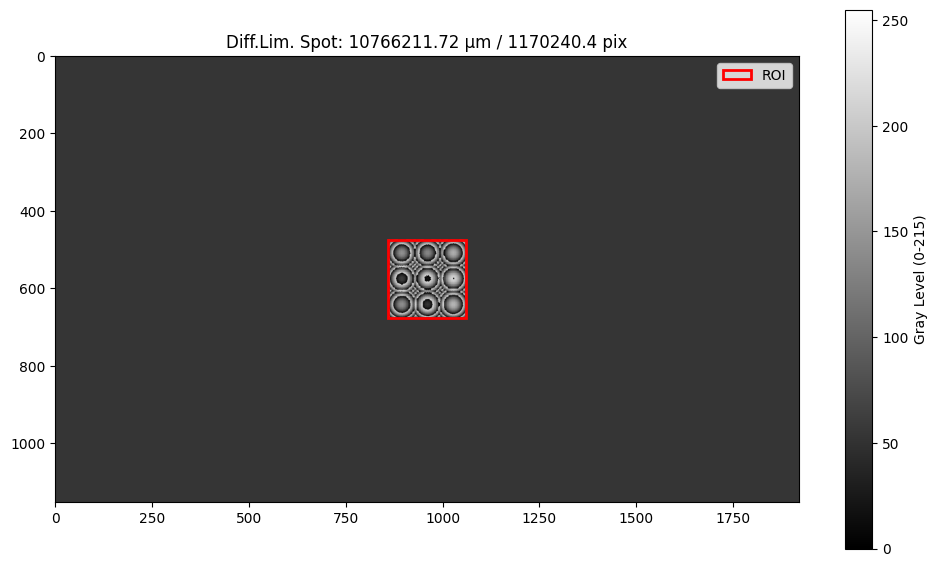

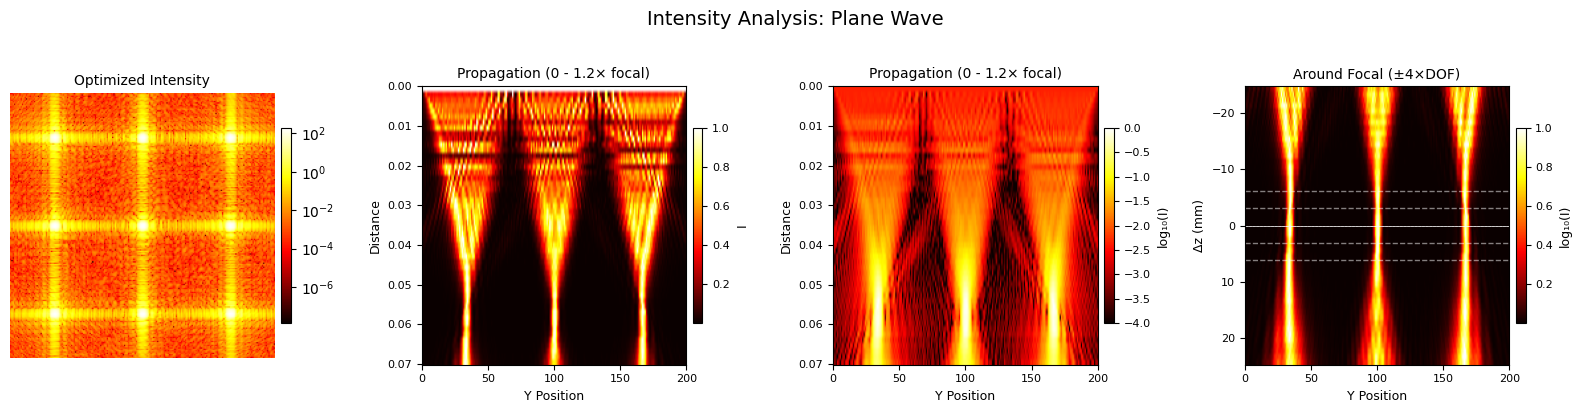

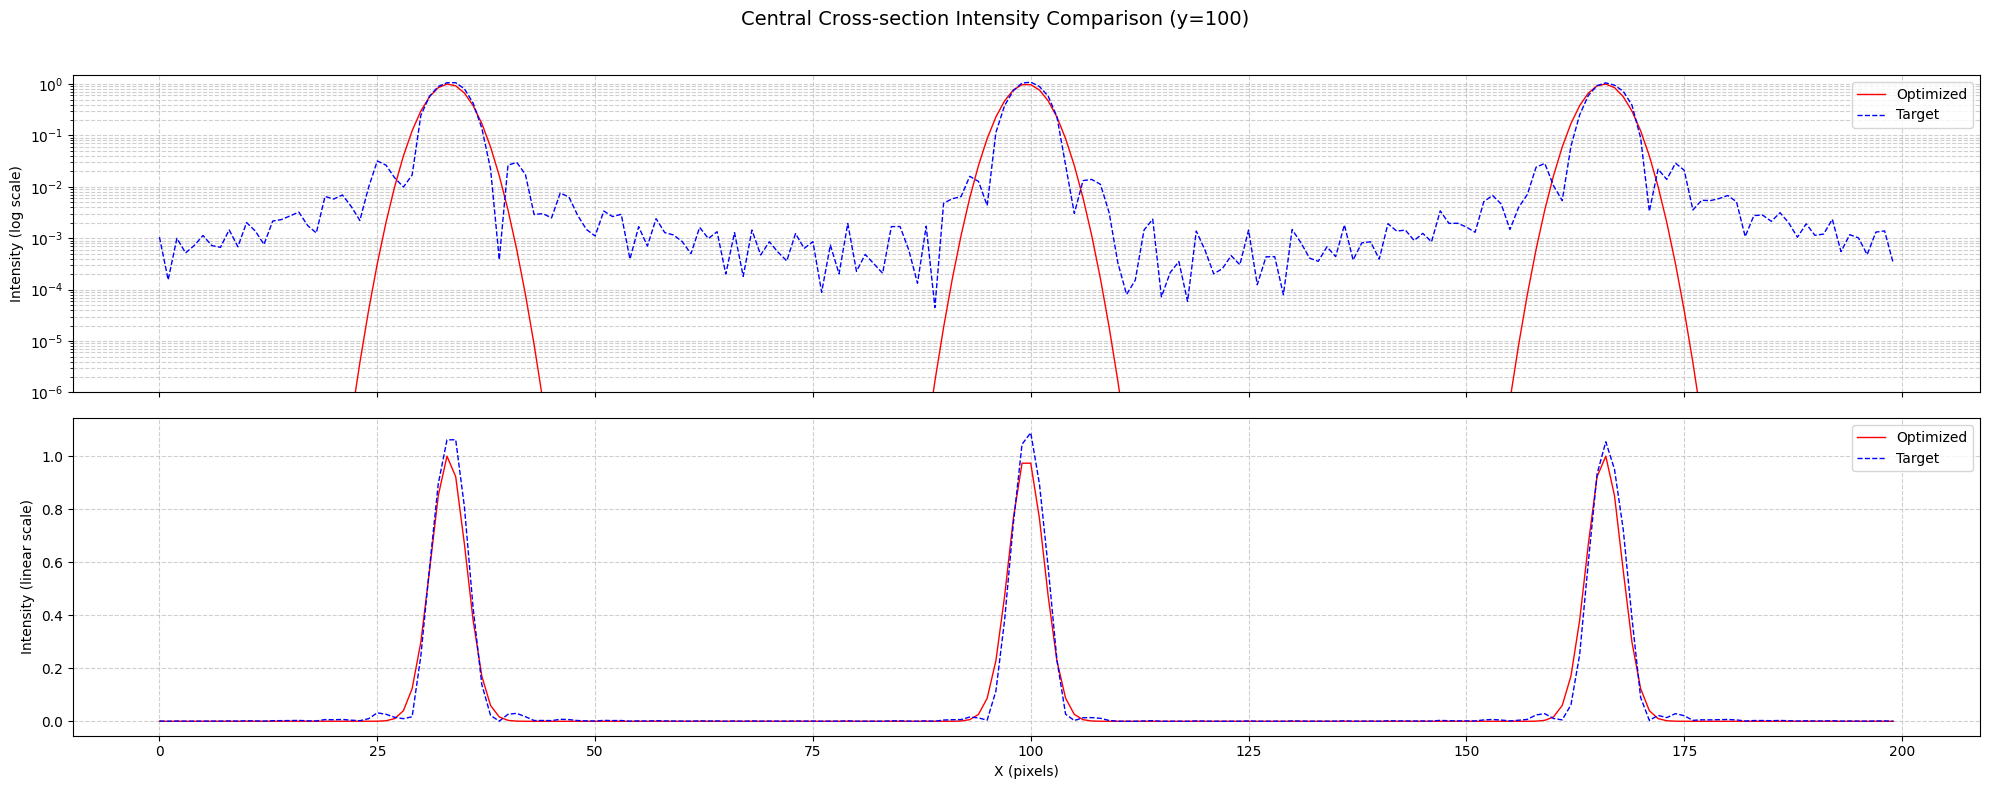

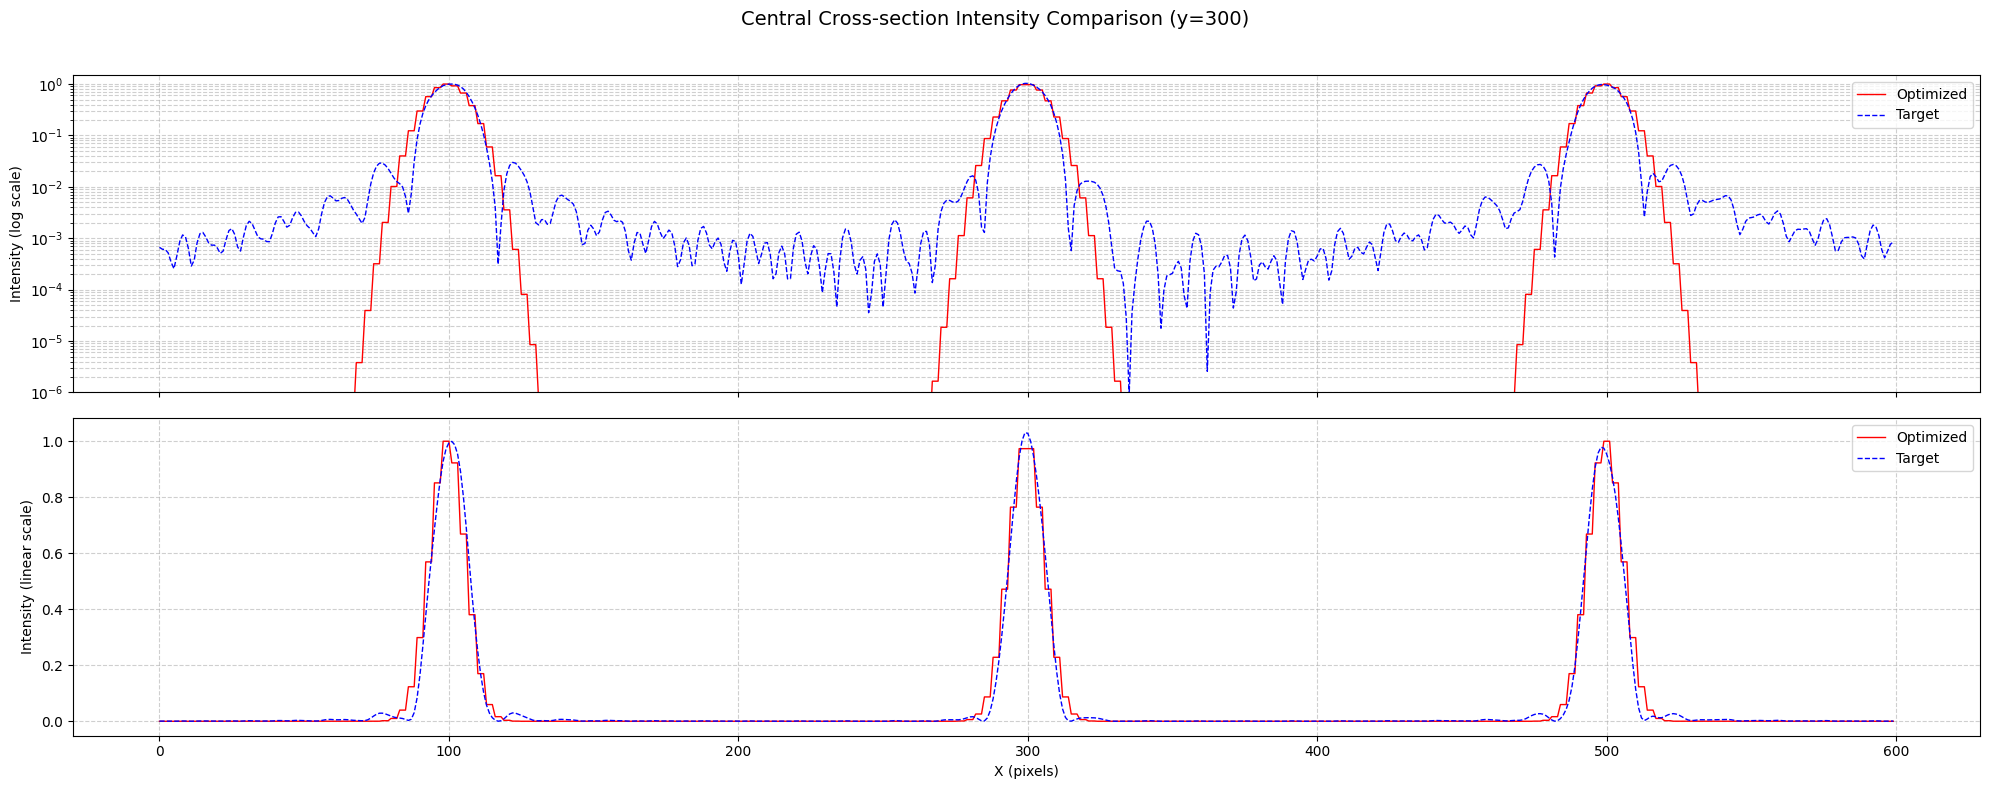

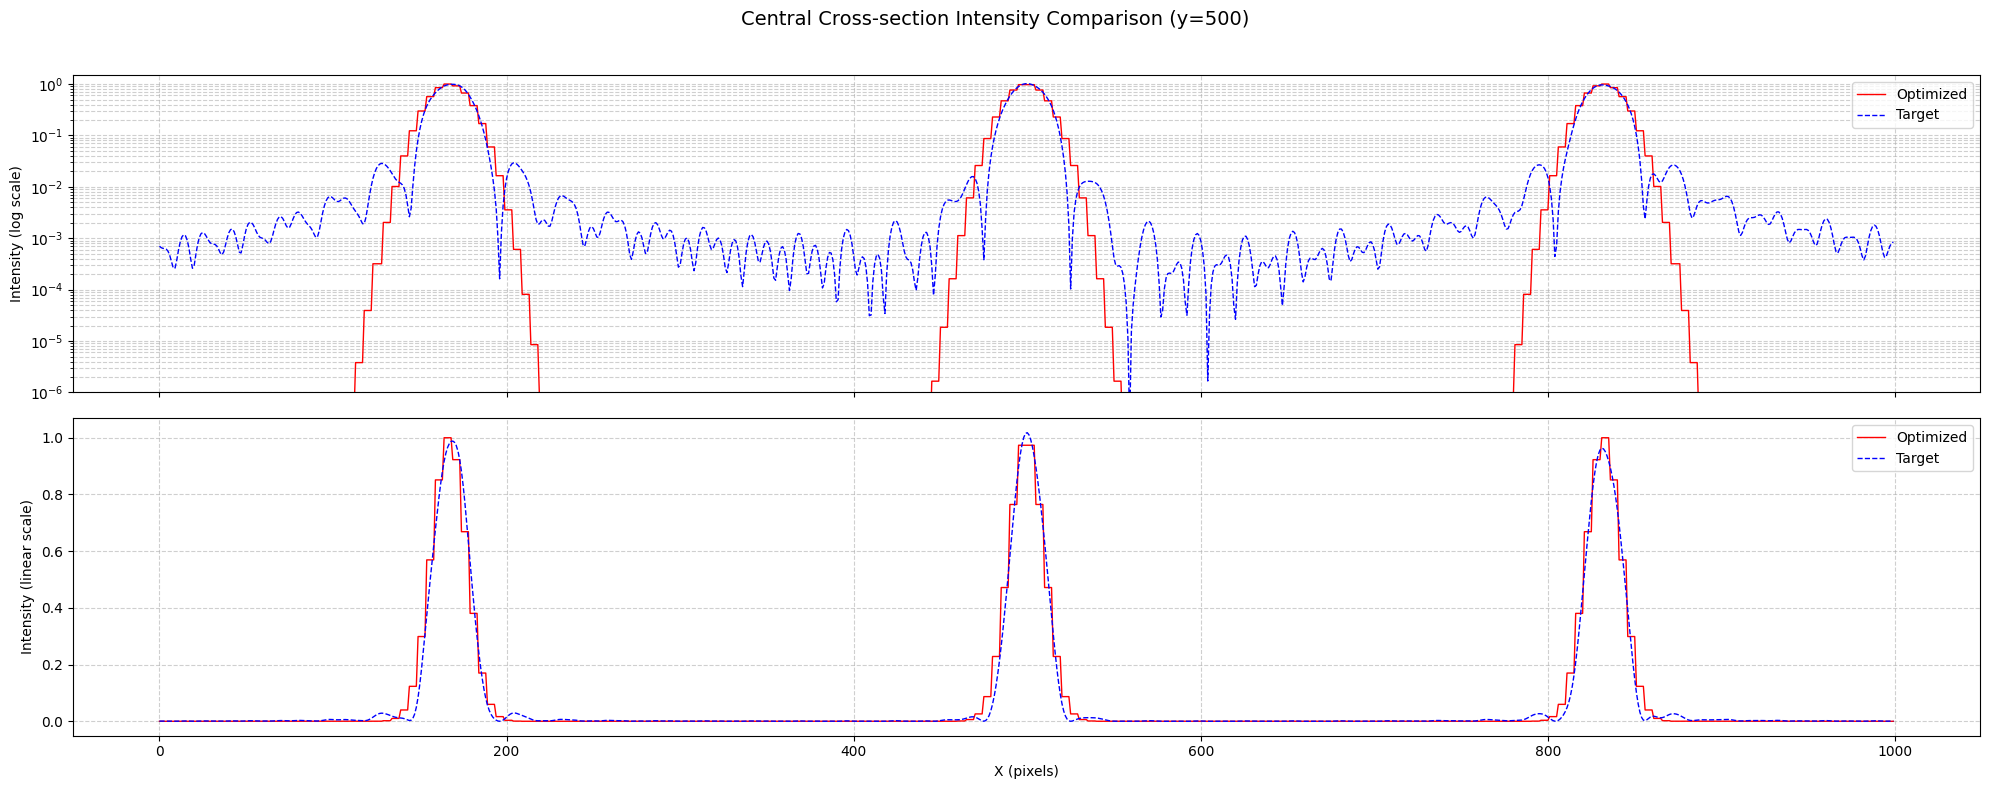


Focusing Efficiency Analysis
Number of focal spots: 9 (M=3x3)

Encircled Energy Calculation:
  Radius: 5.38 pixels = 49.5 μm


c:\Users\zihan\Desktop\code\slm_project\visualization.py:438: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=10)


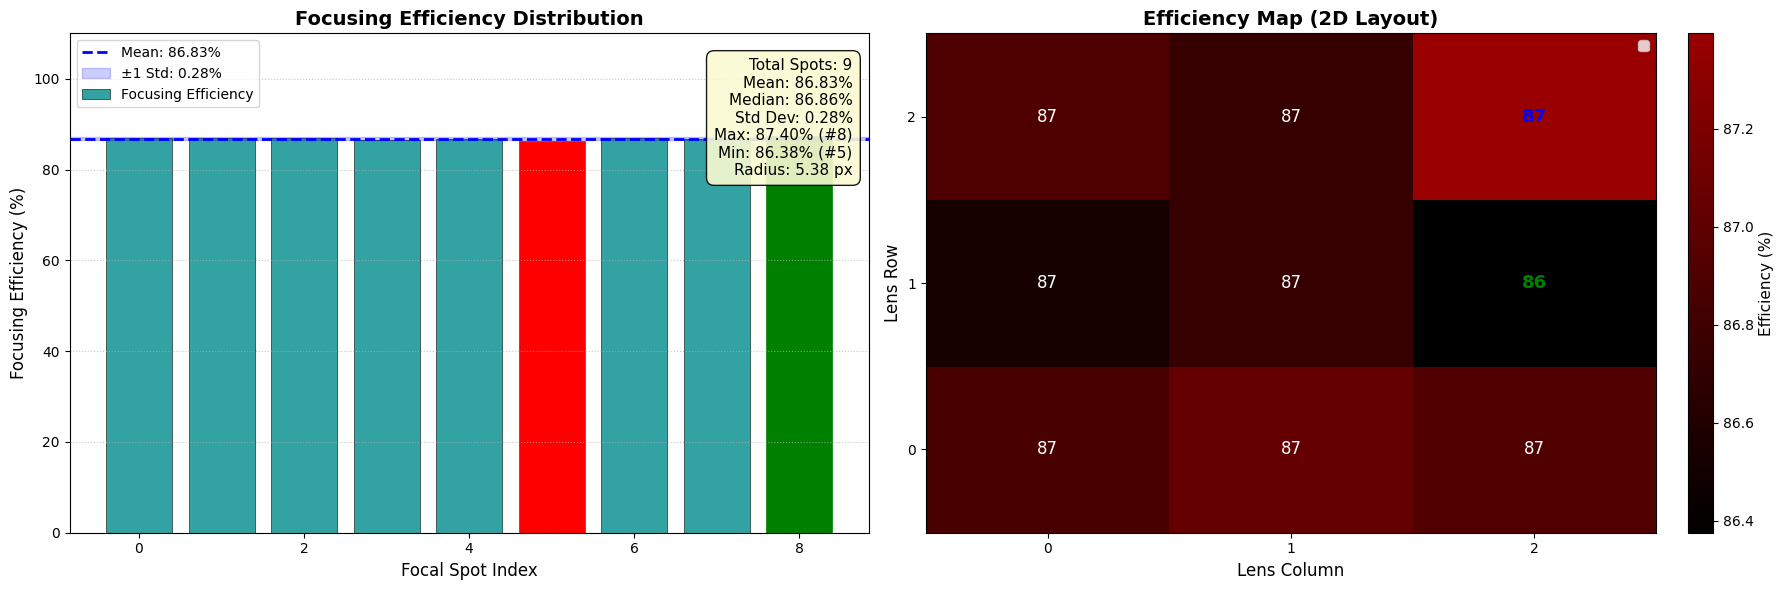


Focusing Efficiency Analysis
Number of focal spots: 9 (M=3x3)

Encircled Energy Calculation:
  Radius: 16.15 pixels = 49.5 μm


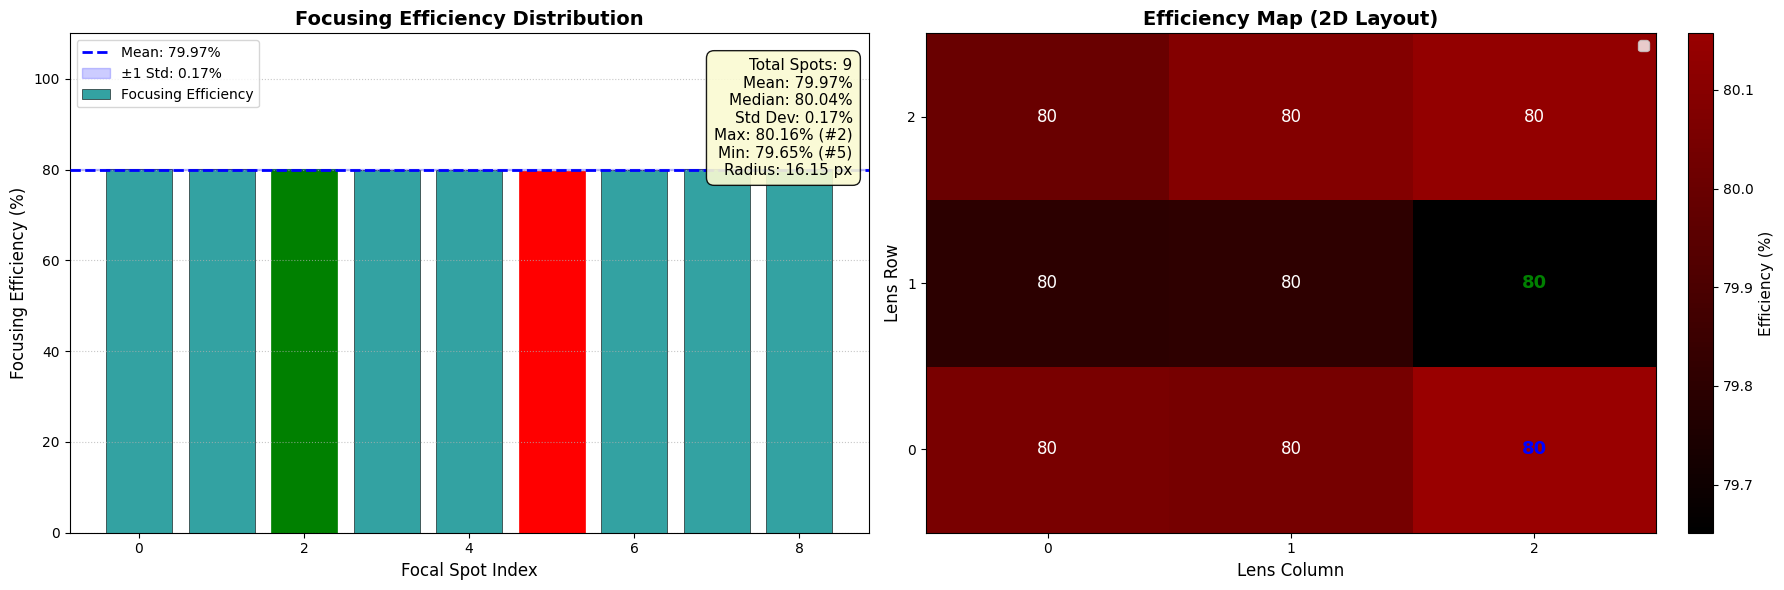


Focusing Efficiency Analysis
Number of focal spots: 9 (M=3x3)

Encircled Energy Calculation:
  Radius: 26.92 pixels = 49.5 μm


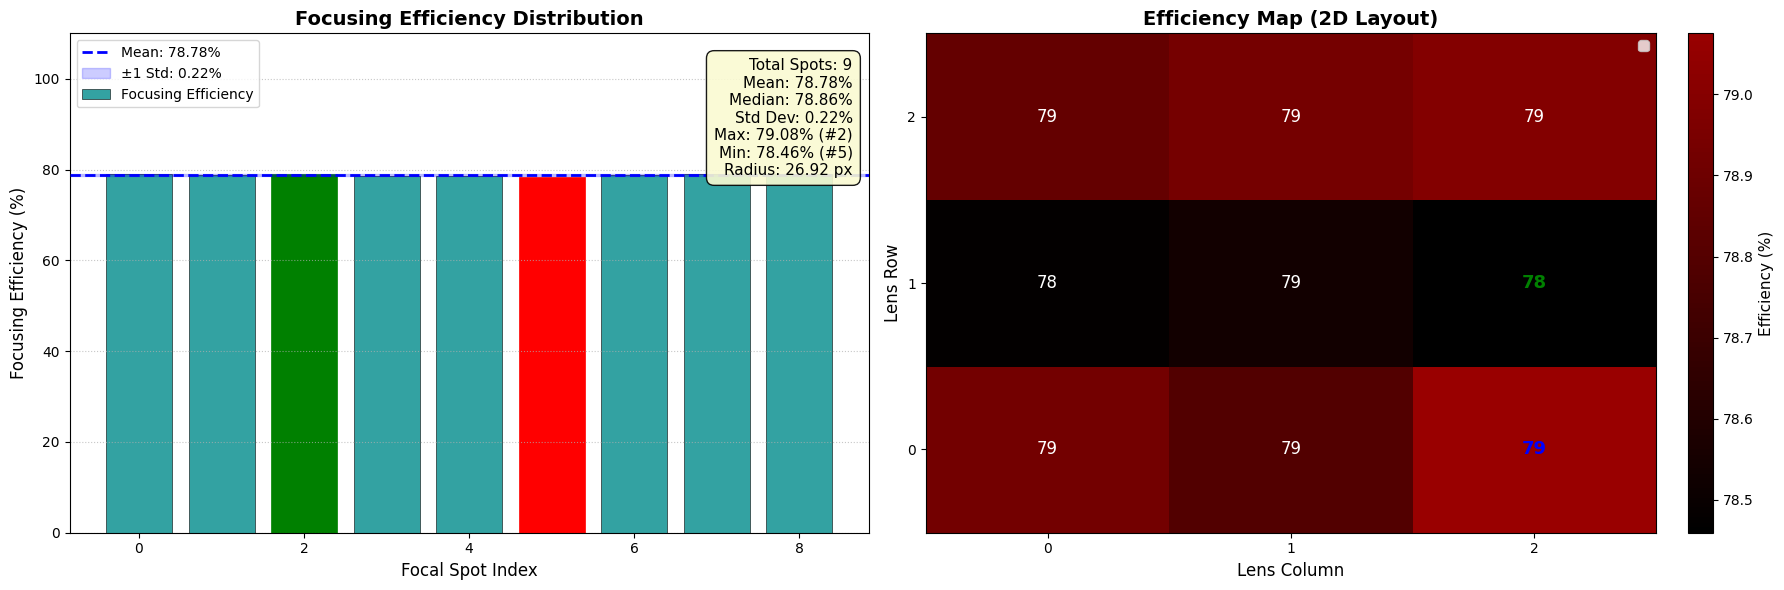

In [5]:
from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
# 可视化
plot_phase(Optimizer)
plot_2d_comparisons(Optimizer)
plot_cross_sections(Optimizer,upsampling=1.0)
plot_cross_sections(Optimizer,upsampling=3)
plot_cross_sections(Optimizer,upsampling=5)

plot_energy_distribution(Optimizer,upsampling=1)
plot_energy_distribution(Optimizer,upsampling=3)
plot_energy_distribution(Optimizer,upsampling=5)
